In [1]:
import numpy as np
import pandas as pd

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import BaggingClassifier

#qiskit
from qiskit import *
from qiskit.circuit.library import ZFeatureMap
from qiskit.utils import QuantumInstance, algorithm_globals
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import QuantumKernel

import warnings
warnings.filterwarnings('ignore')

: 

In [ ]:
data = pd.read_csv('Cleveland Dataset.csv')

## QSVC

In [ ]:
X = data[['ca','cp','thal','exang','slope']]
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

samples = np.append(X_train, X_test, axis=0)
minmax_scaler = MinMaxScaler((0, 1)).fit(samples)
X_train = minmax_scaler.transform(X_train)
X_test = minmax_scaler.transform(X_test)

In [ ]:
# number of qubits is equal to the number of features
num_qubits = 5
# regularization parameter
C = 1000

In [ ]:
algorithm_globals.random_seed = 12345

backend = QuantumInstance(
    BasicAer.get_backend("statevector_simulator"),
    seed_simulator=algorithm_globals.random_seed,
    seed_transpiler=algorithm_globals.random_seed,
)

feature_map = ZFeatureMap(feature_dimension=num_qubits, reps=2)

qkernel = QuantumKernel(feature_map=feature_map, quantum_instance=backend)

qsvc = QSVC(quantum_kernel=qkernel, C=C)

In [ ]:
# training
qsvc.fit(X_train,y_train)

# testing
qsvc_score = qsvc.score(X_test, y_test)
print(f"QSVC classification test score: {qsvc_score}")

QSVC classification test score: 0.8852459016393442


## Bagging-QSVC

In [ ]:
# bagging 
pipeline = make_pipeline(MinMaxScaler(), qsvc)

# Instantiate the bagging classifier
bgclassifier = BaggingClassifier(base_estimator=pipeline, n_estimators=100, 
                                 random_state=1, n_jobs=-1)

# Fit the bagging classifier
bgclassifier.fit(X_train, y_train)

# Model scores on test and training data
print(f"Model test Score: {bgclassifier.score(X_test, y_test)*100:.2f}%")
print(f"Model training Score: {bgclassifier.score(X_train, y_train)*100:.2f}%")

Model test Score: 90.16%
Model training Score: 90.08%


## SHAP library

In [ ]:
import shap

# Load JS visualization code to notebook
shap.initjs() # display the plots 

In [ ]:
# shap_vals = shap_values_K[1]   # class 1 = heart disease
# SHAP Beeswarm plot
shap.summary_plot(shap_values_K[1], X_test, feature_names= features)

NameError: name 'shap_values_K' is not defined

In [ ]:
selected_cols = ['ca', 'cp', 'thal', 'exang', 'slope']


In [ ]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"bgclassifier type: {type(bgclassifier)}")

X_train shape: (242, 5)
X_test shape:  (61, 5)
bgclassifier type: <class 'sklearn.ensemble._bagging.BaggingClassifier'>


100%|██████████| 20/20 [36:32<00:00, 109.60s/it]


Final SHAP Matrix Shape: (20, 5)
Final Data Shape:        (20, 5)


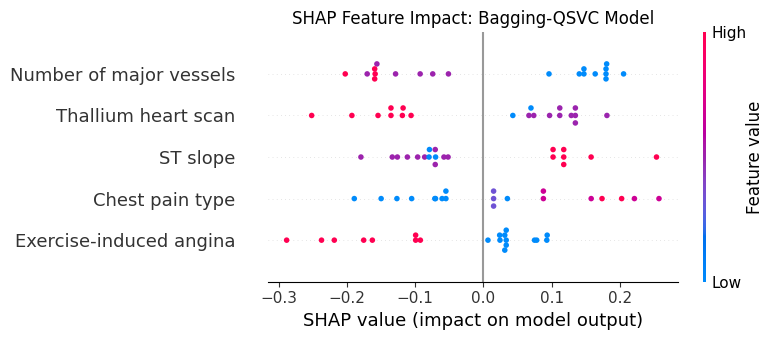

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1) CONFIGURATION
# ----------------------------------------------------------
selected_cols = ['ca', 'cp', 'thal', 'exang', 'slope']
feature_names = [
    'Number of major vessels',
    'Chest pain type',
    'Thallium heart scan',
    'Exercise-induced angina',
    'ST slope'
]

# ----------------------------------------------------------
# 2) CONVERT NUMPY ARRAYS TO DATAFRAMES
# ----------------------------------------------------------
X_train_df = pd.DataFrame(X_train, columns=selected_cols)
X_test_df  = pd.DataFrame(X_test,  columns=selected_cols)

# ----------------------------------------------------------
# 3) BACKGROUND & EXPLAINER
# ----------------------------------------------------------
background_np = X_train_df.sample(n=50, random_state=42).values

def predict_class1_proba(X):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=selected_cols)
    return bgclassifier.predict_proba(X)[:, 1]

explainer_K = shap.KernelExplainer(
    predict_class1_proba,
    data=background_np
)

# ----------------------------------------------------------
# 4) COMPUTE SHAP VALUES
# ----------------------------------------------------------
X_test_subset = X_test_df.iloc[:20].values

raw_shap_values = explainer_K.shap_values(X_test_subset, nsamples=100)

# ----------------------------------------------------------
# 5) EXTRACT & VALIDATE SHAP MATRIX
# ----------------------------------------------------------
target_shap_values = np.array(raw_shap_values)

if isinstance(raw_shap_values, list):
    target_shap_values = np.array(raw_shap_values[0])

if target_shap_values.ndim == 1:
    target_shap_values = target_shap_values.reshape(1, -1)

if target_shap_values.shape[1] > len(selected_cols):
    target_shap_values = target_shap_values[:, :len(selected_cols)]

# ----------------------------------------------------------
# 6) ALIGN DISPLAY DATA
# ----------------------------------------------------------
display_data_np = X_test_subset[:target_shap_values.shape[0]]

print(f"Final SHAP Matrix Shape: {target_shap_values.shape}")
print(f"Final Data Shape:        {display_data_np.shape}")

assert target_shap_values.shape == display_data_np.shape, \
    f"Shape mismatch: SHAP {target_shap_values.shape} vs data {display_data_np.shape}"

# ----------------------------------------------------------
# 7) PLOT
# ----------------------------------------------------------
plt.figure(figsize=(12, 8))
shap.summary_plot(
    target_shap_values,
    display_data_np,
    feature_names=feature_names,
    plot_type="dot",
    show=False
)
plt.title("SHAP Feature Impact: Bagging-QSVC Model")
plt.tight_layout()
plt.show()

### Code without kmeans or sample
 ..KernelExplainer
explainer_K = shap.KernelExplainer(
    bgclassifier.predict_proba,
    data=X_train[selected_cols]
)

 ..SHAP values for test data (same columns!)
shap_values_K = explainer_K.shap_values(X_test[selected_cols])

 Select class 1 (heart disease)
shap_vals = shap_values_K[1]

 ..Feature names (human-readable)
feature_names = [
    'Number of major vessels',
    'Chest pain type',
    'Thallium heart scan',
    'Exercise-induced angina',
    'ST slope'
]

 ..SHAP bar plot
shap.summary_plot(
    shap_vals,
    X_test[selected_cols],
    feature_names=feature_names,
    plot_type="bar"
)


In [ ]:
# KernelExplainer
explainer_K = shap.KernelExplainer(bgclassifier.predict_proba, data=X_train)
shap_values_K = explainer_K.shap_values(X_test)

#   bgclassifier.predict_proba,
#    background
#)

#shap_values_K = explainer_K.shap_values(X_test)


100%|██████████| 61/61 [3:54:08<00:00, 230.31s/it]    


In [ ]:
features= ['Number of major vessels','Chest pain type',
           'Thallium heart scan','Exercise-induced angina',
           'ST slope']

In [ ]:
# SHAP bar plot
shap.summary_plot(shap_values_K, X_test, feature_names= features)

NameError: name 'shap_values_K' is not defined

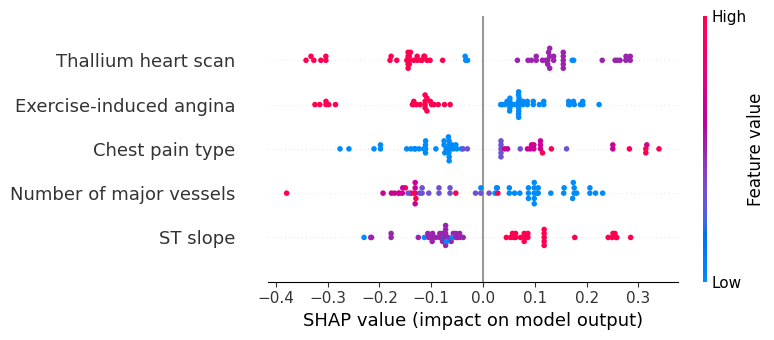

In [ ]:
# SHAP Beeswarm plot
shap.summary_plot(shap_values_K[1], X_test, feature_names= features)

In [ ]:
#Explainer
explainer = shap.Explainer(bgclassifier.predict, X_test)
# Calculates the SHAP values 
shap_values = explainer(X_test)

KeyboardInterrupt: 

In [ ]:
# SHAP force plot 
shap.plots.force(shap_values[1], feature_names=features)

NameError: name 'shap_values' is not defined

: 

In [ ]:
# Stacked SHAP force plot 
shap.force_plot(explainer_K.expected_value[1], shap_values_K[1], X_test, feature_names= features)

PermutationExplainer explainer: 31it [00:11,  1.67s/it]                        


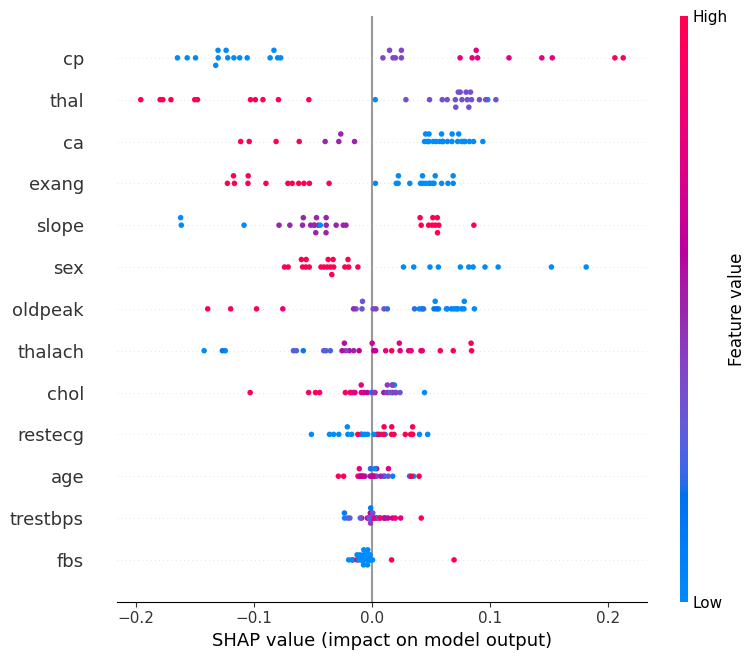

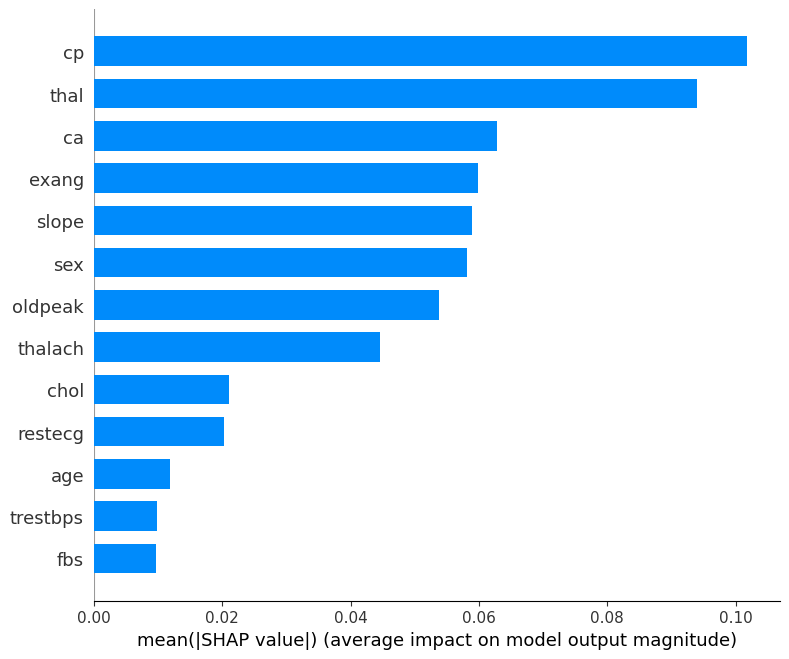

In [ ]:
# ==========================================================
# SHAP EXPLAINABILITY – FINAL WORKING VERSION (FIXED)
# ==========================================================

import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ----------------------------------------------------------
# 1) Load Dataset (DIRECT PATH – NO ERRORS)
# ----------------------------------------------------------

CSV_PATH = r"D:\PROJECT\Collage\Explainable_Heart_Disease_Prediction_Using_Ensemble-Quantum_ML-main\Cleveland Dataset.csv"  # 🔴 CHANGE THIS
df = pd.read_csv(CSV_PATH)

# Ensure binary target
if "target" not in df.columns:
    df["target"] = (df["num"] > 0).astype(int)

# ----------------------------------------------------------
# 2) Train–Test Split
# ----------------------------------------------------------

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns
)

# ----------------------------------------------------------
# 3) Train SVM
# ----------------------------------------------------------

model = SVC(kernel="rbf", probability=True, random_state=42)
model.fit(X_train_scaled, y_train)

# ----------------------------------------------------------
# 4) SHAP – SVM CORRECT VERSION
# ----------------------------------------------------------

X_background = X_train_scaled.iloc[:100]
X_explain = X_test_scaled.iloc[:30]

explainer = shap.Explainer(
    model.predict_proba,   # ✅ callable
    X_background
)

shap_values = explainer(X_explain)

# Handle SHAP output safely
shap_vals = shap_values.values if hasattr(shap_values, "values") else shap_values

# Binary classification → select class 1
if len(shap_vals.shape) == 3:
    shap_vals = shap_vals[:, :, 1]


# ----------------------------------------------------------
# 5) SHAP SUMMARY PLOT
# ----------------------------------------------------------

shap.summary_plot(shap_vals, X_explain)

# ----------------------------------------------------------
# 6) SHAP BAR PLOT
# ----------------------------------------------------------

shap.summary_plot(shap_vals, X_explain, plot_type="bar")


In [ ]:
import shap
import numpy as np

shap.initjs()

# Larger background for stability
background = shap.sample(X_train, 100)

explainer = shap.KernelExplainer(
    bgclassifier.predict_proba,
    background
)

# Explain ALL test samples
shap_values = explainer.shap_values(X_test)

# Proper summary plot (class 1)
shap.summary_plot(
    shap_values[1],
    X_test,
    feature_names=data.columns[:-1],
    plot_type="dot"
)


KeyboardInterrupt: 

100%|██████████| 30/30 [53:26<00:00, 106.87s/it] 


<Figure size 2000x4500 with 0 Axes>

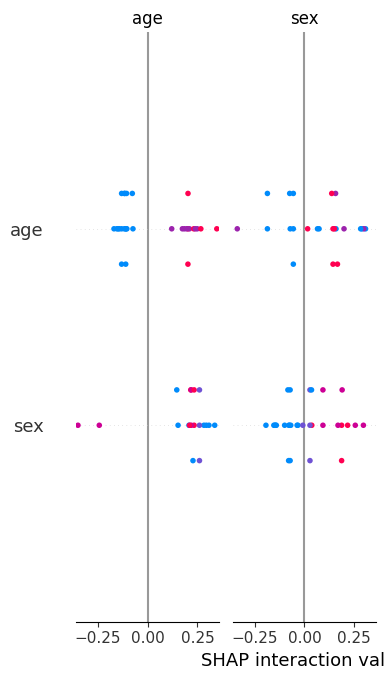

In [ ]:


import shap
import numpy as np
import matplotlib.pyplot as plt

# Initialize JS
shap.initjs()


background = shap.sample(X_train, 30)   

explainer = shap.KernelExplainer(
    bgclassifier.predict_proba,
    background
)

# Explain only few test samples
shap_values = explainer.shap_values(X_test[:30])

plt.figure(figsize=(20,45))
# Summary plot
shap.summary_plot(
    shap_values,
    X_test[:30],
    feature_names=data.columns[:-1],
    plot_type="bar"
)



100%|██████████| 61/61 [3:45:29<00:00, 221.79s/it]  


<Figure size 2000x4500 with 0 Axes>

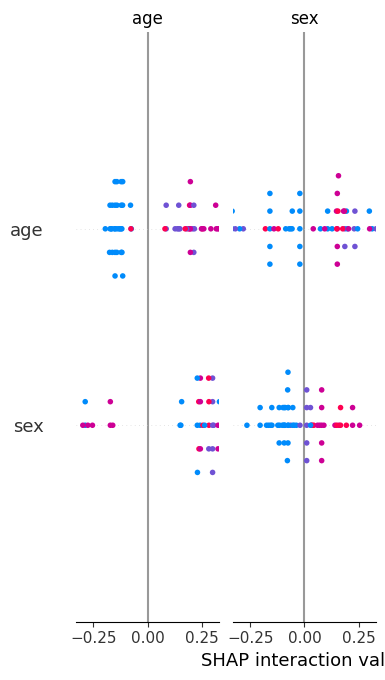

In [ ]:

# Initialize JS
shap.initjs()


background = shap.sample(X_train, 100)   

explainer = shap.KernelExplainer(
    bgclassifier.predict_proba,
    background
)

# Explain only few test samples
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(20,45))
# Summary plot
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=data.columns[:-1],
    plot_type="bar"
)

